<div style="background: linear-gradient(135deg, #1b4332 0%, #2d6a4f 60%, #52b788 100%); padding: 40px; border-radius: 16px; color: white; text-align: center; margin-bottom: 20px;">
  <h1 style="font-size: 2em; margin-bottom: 8px;">🌱 SmartRoot</h1>
  <h2 style="font-weight: 300; font-size: 1.15em; margin-bottom: 18px;">Sistema portátil para estimación del potencial mátrico del suelo<br>mediante resistividad eléctrica y aprendizaje automático</h2>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 16px 0;">
  <h3 style="font-weight: 400;">📓 Notebook 02 — Programación Básica en Python</h3>
  <p style="opacity: 0.85;">Variables · Condicionales · Ciclos · Funciones · Indicadores · Semáforo</p>
  <p style="opacity: 0.7; font-size: 0.9em;">Fundamentos de Programación Científica · Maestría en Automatización y Control Industrial</p>
</div>

---

## ¿Qué construimos en este notebook?

En el **Notebook 01** exploramos y limpiamos el dataset. Ahora usamos ese dataset limpio para aplicar todos los fundamentos de programación en Python directamente sobre los datos reales de sensores de suelo.

Al terminar este notebook habrás:
- Declarado y usado variables relacionadas con el problema real.
- Validado la calidad de los datos con condicionales.
- Recorrido los registros con ciclos `for` y `while`.
- Construido funciones reutilizables para calcular indicadores del suelo.
- Implementado un **sistema de semáforo** (🟢🟡🔴) para decisiones de riego.
- Generado la tabla de indicadores de desempeño (KPIs) del sistema SmartRoot.

---

### 📌 Contexto: ¿qué hallamos en el EDA?

El EDA (Notebook 01) nos dejó resultados clave que guían todo lo que haremos aquí:

| Hallazgo | Valor | Implicación para este notebook |
|---|---|---|
| Correlación Gypsum↔ψ | r = **0.95** | Los sensores resistivos son válidos como predictor |
| Período limpio | **13 May → 4 Jul 2016** | 2.494 registros completamente limpios |
| Estado hídrico mayoritario | **74.5% en zona óptima** (100–300 hPa) | El suelo estuvo bien manejado |
| 10.2% de registros húmedos | ψ ≤ 100 hPa | Sin necesidad de riego urgente |
| 15.3% de registros secos | ψ > 300 hPa | Episodios que requieren riego |
| Temperatura = 0 en 24.8% | Sensor MPS6 fuera de rango en madrugadas | Se corrige usando temperatura del aire |

---
## Sección 0 — Configuración del entorno

In [1]:
# ============================================================
# SMARTROOT — Celda de inicio (ejecutar siempre primero)
# ============================================================
from google.colab import drive
import sys, os
drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/POSGRADO/2026-1/FUNDAMENTOS DE PROGRAMACIÓN CIENTÍFICA/CLASES/PROYECTO_FINAL'
DATA_RAW  = f'{BASE}/data/raw'
DATA_PROC = f'{BASE}/data/processed'
FIGS      = f'{BASE}/outputs/figuras'
TABS      = f'{BASE}/outputs/tablas'
SRC       = f'{BASE}/src'
sys.path.insert(0, SRC)

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores del proyecto
VERDE    = '#40916c'
AMARILLO = '#f4a261'
ROJO     = '#e63946'
AZUL     = '#457b9d'
GRIS     = '#6c757d'

plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})

print('✅ Entorno listo.')

Mounted at /content/drive
✅ Entorno listo.


---
## Sección 1 — Variables y carga del dataset

### ¿Qué es una variable en Python?

Una **variable** es un nombre que le damos a un valor guardado en la memoria del computador. En SmartRoot usamos variables para guardar configuraciones, umbrales de decisión y referencias al dataset — todo con nombres que describen exactamente qué representan en el contexto del problema de riego.

In [2]:
# ── Variables de configuración del proyecto SmartRoot ─────────────────────
# Estas variables centralizan los parámetros clave del sistema.
# Si necesitamos cambiar un umbral, lo hacemos aquí y afecta todo el código.

# --- Metadatos del sistema ---
NOMBRE_PROYECTO   = 'SmartRoot'                        # str: nombre del sistema
VERSION           = '1.0'                              # str: versión del software
CULTIVO_OBJETIVO  = 'Hortalizas / café / aguacate'     # str: cultivos de aplicación
UNIDAD_PSI        = 'hPa'                              # str: unidad del potencial mátrico
RESOLUCION_MIN    = 30                                 # int: minutos entre mediciones

# --- Umbrales agronómicos del potencial mátrico (ψ) ---
# Basados en literatura agronómica estándar para suelos francos.
# Referencia: Rawls et al. (1982); FAO Irrigation Manual
PSI_HUMEDO_MAX    = 100    # int [hPa]: por debajo de este valor → suelo muy húmedo
PSI_OPTIMO_MAX    = 300    # int [hPa]: entre 100 y 300 → zona óptima para cultivos
PSI_SECO_MIN      = 300    # int [hPa]: por encima → suelo seco, programar riego
PSI_CRITICO       = 400    # int [hPa]: por encima → riego urgente

# --- Parámetros físicos del suelo (Van Genuchten, medidos en laboratorio) ---
# Estos valores se obtuvieron de los ensayos de laboratorio del sitio JKI
# y están almacenados en el archivo vG_JKI_params.xlsx del dataset.
VG_ALPHA   = 0.0264   # float: parámetro de distribución de tamaño de poros [1/cm]
VG_N       = 3.044    # float: parámetro de uniformidad de la distribución de poros [-]
VG_THETA_R = 0.007    # float: humedad residual (mínima posible) [m³/m³]
VG_THETA_S = 0.361    # float: humedad de saturación (máxima posible) [m³/m³]

# --- Parámetros del sensor Gypsum (EPM-resistencia eléctrica) ---
# El Gypsum es el sensor de bajo costo cuyo principio físico usa nuestra tesis
GYPSUM_PSI_MIN  = 50.0    # float [hPa]: mínimo valor detectable por el sensor
GYPSUM_PSI_MAX  = 350.0   # float [hPa]: máximo valor detectable por el sensor
GYPSUM_N_REPLIC = 4       # int: número de réplicas instaladas en el experimento

# --- Estadísticas observadas en el EDA (Notebook 01) ---
# Guardamos los resultados del EDA como variables para no recalcularlos
EDA_CORRELACION_GYPSUM = 0.949   # float: r(Gypsum, ψ_ref) — confirmado en el EDA
EDA_PCT_OPTIMO         = 74.5    # float [%]: porcentaje del tiempo en zona óptima
EDA_PCT_HUMEDO         = 10.2    # float [%]: porcentaje del tiempo en zona húmeda
EDA_PCT_SECO           = 15.3    # float [%]: porcentaje del tiempo en zona seca
EDA_TOTAL_REGISTROS    = 2494    # int: filas en el dataset limpio

print(f'📋 CONFIGURACIÓN DEL SISTEMA {NOMBRE_PROYECTO} v{VERSION}')
print(f'   Cultivo objetivo      : {CULTIVO_OBJETIVO}')
print(f'   Resolución temporal   : {RESOLUCION_MIN} minutos')
print(f'   Unidad de medición    : {UNIDAD_PSI}')
print()
print(f'   UMBRALES AGRONÓMICOS DEL POTENCIAL MÁTRICO (ψ):')
print(f'   Húmedo    : ψ ≤ {PSI_HUMEDO_MAX} {UNIDAD_PSI}        → sin necesidad de riego')
print(f'   Óptimo    : {PSI_HUMEDO_MAX} < ψ ≤ {PSI_OPTIMO_MAX} {UNIDAD_PSI}  → humedad ideal para raíces')
print(f'   Seco      : {PSI_SECO_MIN} < ψ ≤ {PSI_CRITICO} {UNIDAD_PSI}  → programar riego')
print(f'   Crítico   : ψ > {PSI_CRITICO} {UNIDAD_PSI}        → riego urgente, riesgo de pérdida')
print()
print(f'   RESULTADO CLAVE DEL EDA:')
print(f'   Correlación Gypsum↔ψ = {EDA_CORRELACION_GYPSUM} → valida el principio de la tesis ✅')

📋 CONFIGURACIÓN DEL SISTEMA SmartRoot v1.0
   Cultivo objetivo      : Hortalizas / café / aguacate
   Resolución temporal   : 30 minutos
   Unidad de medición    : hPa

   UMBRALES AGRONÓMICOS DEL POTENCIAL MÁTRICO (ψ):
   Húmedo    : ψ ≤ 100 hPa        → sin necesidad de riego
   Óptimo    : 100 < ψ ≤ 300 hPa  → humedad ideal para raíces
   Seco      : 300 < ψ ≤ 400 hPa  → programar riego
   Crítico   : ψ > 400 hPa        → riego urgente, riesgo de pérdida

   RESULTADO CLAVE DEL EDA:
   Correlación Gypsum↔ψ = 0.949 → valida el principio de la tesis ✅


In [3]:
# ── Carga del dataset limpio generado en el Notebook 01 ───────────────────
# dataset_limpio.csv: 2.494 registros, período 13 May – 4 Jul 2016,
# resolución 30 minutos, sin valores faltantes (todos los NaN eliminados).

df = pd.read_csv(f'{DATA_PROC}/dataset_limpio.csv', index_col=0, parse_dates=True)

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Período   : {df.index.min().date()} → {df.index.max().date()}')
print(f'   Columnas  : {list(df.columns)}')
print()
print('Vista previa de los primeros 5 registros:')
print(df.head().round(2).to_string())

# ── Nota sobre la temperatura (hallazgo del EDA) ──────────────────────────
# El histograma del EDA mostró un pico pronunciado en 0°C para temp_c.
# Corresponde a que el sensor MPS6 reporta exactamente 0 cuando la
# temperatura del suelo está por debajo de su rango de operación.
# Este es un problema real de calibración que corregiremos en la Sección 2.
n_temp_cero = (df['temp_c'] == 0).sum()
print(f'\n⚠️  Hallazgo del EDA confirmado: {n_temp_cero} registros ({n_temp_cero/len(df)*100:.1f}%) tienen temp_c = 0')
print('   → Sensor MPS6 fuera de rango de medición en madrugadas frías.')
print('   → Corrección: usar temp_aire_c × 0.85 como aproximación del suelo.')

✅ Dataset cargado: 2,494 filas × 8 columnas
   Período   : 2016-05-13 → 2016-07-04
   Columnas  : ['psi_ref_hpa', 'psi_gypsum_hpa', 'psi_vg_hpa', 'theta_pct', 'temp_c', 'precip_mm', 'rad_wm2', 'temp_aire_c']

Vista previa de los primeros 5 registros:
                     psi_ref_hpa  psi_gypsum_hpa  psi_vg_hpa  theta_pct  temp_c  precip_mm  rad_wm2  temp_aire_c
2016-05-13 13:00:00       322.63          277.50      444.56      19.20     0.0        0.0      838         21.2
2016-05-13 13:30:00       321.97          278.25      444.80      19.19     0.0        0.0      815         21.6
2016-05-13 14:00:00       320.86          279.00      444.14      19.22     0.0        0.0      778         21.8
2016-05-13 14:30:00       319.56          280.25      443.92      19.24     0.0        0.0      734         21.8
2016-05-13 15:00:00       318.57          281.50      443.87      19.24     0.0        0.0      681         21.8

⚠️  Hallazgo del EDA confirmado: 619 registros (24.8%) tienen temp_c =

---
## Sección 2 — Validación básica de datos con condicionales

### ¿Por qué validar los datos?

Antes de usar cualquier dato para tomar decisiones de riego, debemos verificar que esté dentro de rangos físicamente posibles. Un sensor dañado podría reportar valores imposibles (como ψ negativo o temperatura de 100°C) que llevarían a decisiones incorrectas.

### La estructura `if / elif / else`

Permite que el programa tome diferentes caminos según el valor de una variable:
```python
if condicion_1:      # si se cumple esta condición
    accion_1
elif condicion_2:    # si no se cumplió la 1 pero sí esta
    accion_2
else:                # si ninguna condición anterior se cumplió
    accion_por_defecto
```

In [4]:
# ── Rangos físicamente válidos para cada variable ────────────────────────
# Estos rangos se basan en la física del suelo y las especificaciones
# técnicas de los sensores del dataset Jackisch et al. (2018).
RANGOS_VALIDOS = {
    'psi_ref_hpa'   : (0,    2000),   # hPa: 0=saturado, >1500=marchitez permanente
    'psi_gypsum_hpa': (50,   350),    # hPa: rango operativo del bloque de yeso Gypsum
    'psi_vg_hpa'    : (0,    8000),   # hPa: Van Genuchten — rango teórico amplio
    'theta_pct'     : (0.7,  36.1),   # %: entre θ_r×100 y θ_s×100
    'temp_c'        : (-5,   50),     # °C: rango razonable del suelo agrícola
    'precip_mm'     : (0,    200),    # mm: precipitación por intervalo de 30 min
    'rad_wm2'       : (0,    1200),   # W/m²: máximo solar en superficie terrestre
    'temp_aire_c'   : (-20,  50),     # °C: temperatura ambiente razonable
}


# ── Función de validación de un registro individual ───────────────────────
def validar_registro(registro, rangos):
    """
    Valida que los valores de un registro estén dentro de rangos físicos.

    Parámetros:
        registro : pd.Series con los valores de una medición
        rangos   : dict {columna: (min_valido, max_valido)}

    Retorna:
        tuple (es_valido: bool, errores: list de str)
    """
    errores = []

    for columna, (minimo, maximo) in rangos.items():
        if columna not in registro.index:
            continue
        valor = registro[columna]

        # Condicional anidado para detectar el tipo de problema
        if pd.isna(valor):
            errores.append(f'{columna}: valor faltante (NaN)')
        elif valor < minimo:
            errores.append(f'{columna}: {valor:.2f} menor que el mínimo permitido ({minimo})')
        elif valor > maximo:
            errores.append(f'{columna}: {valor:.2f} mayor que el máximo permitido ({maximo})')
        else:
            pass   # valor dentro del rango: sin acción necesaria

    es_valido = (len(errores) == 0)
    return es_valido, errores


# ── Aplicar validación a TODO el dataset usando ciclo for ─────────────────
print('🔍 VALIDACIÓN DE CALIDAD DE DATOS — SmartRoot')
print('=' * 62)
print(f'   Validando {len(df):,} registros contra rangos físicos...\n')

registros_validos   = 0
registros_invalidos = 0
log_errores         = []   # lista de tuplas (timestamp, mensaje_error)

# CICLO FOR: recorre cada fila del DataFrame una a una
# iterrows() devuelve pares (índice, fila_como_Series)
for timestamp, fila in df.iterrows():
    es_valido, errores = validar_registro(fila, RANGOS_VALIDOS)

    if es_valido:
        registros_validos += 1
    else:
        registros_invalidos += 1
        for error in errores:
            log_errores.append((timestamp, error))

# Calcular el porcentaje de calidad
pct_validos = registros_validos / len(df) * 100

print(f'   Registros completamente válidos : {registros_validos:,} ({pct_validos:.1f}%)')
print(f'   Registros con al menos 1 alerta : {registros_invalidos:,} ({100-pct_validos:.1f}%)')
print(f'   Total de alertas individuales   : {len(log_errores)}')

# CONDICIONAL if/elif/else: clasificar el nivel de calidad global
if pct_validos >= 95:
    calidad = '🟢 EXCELENTE — apto para modelo ML sin correcciones adicionales'
elif pct_validos >= 80:
    calidad = '🟡 BUENA — requiere corrección puntual de valores límite'
elif pct_validos >= 60:
    calidad = '🟠 REGULAR — necesita limpieza adicional antes del ML'
else:
    calidad = '🔴 DEFICIENTE — revisar sensores y recalibrar el sistema'

print(f'\n   Calidad global del dataset: {calidad}')

# Mostrar las primeras alertas para diagnóstico
if log_errores:
    print(f'\n   Primeras 10 alertas detectadas:')
    for ts, err in log_errores[:10]:
        print(f'     [{ts.strftime("%Y-%m-%d %H:%M")}] ⚠️  {err}')
    if len(log_errores) > 10:
        print(f'     ... ({len(log_errores)-10} alertas más, todas relacionadas con temp_c = 0)')

🔍 VALIDACIÓN DE CALIDAD DE DATOS — SmartRoot
   Validando 2,494 registros contra rangos físicos...

   Registros completamente válidos : 2,494 (100.0%)
   Registros con al menos 1 alerta : 0 (0.0%)
   Total de alertas individuales   : 0

   Calidad global del dataset: 🟢 EXCELENTE — apto para modelo ML sin correcciones adicionales


In [5]:
# ── Corrección iterativa con ciclo WHILE ──────────────────────────────────
# El ciclo while ejecuta un bloque mientras una condición sea verdadera.
# Lo usamos aquí para corregir todos los registros donde temp_c = 0,
# reemplazándolos uno a uno y contando cuántos se corrigen.

# Cuando el sensor MPS6 reporta 0°C (fuera de rango operativo),
# usamos la temperatura del aire × 0.85 como aproximación.
# Fundamento: el suelo amortigua la temperatura del aire en ~15%.

df_corregido = df.copy()   # SIEMPRE trabajar en una copia — nunca modificar el original

n_corregidos = 0    # contador de registros corregidos
i = 0               # índice de la fila actual

# CICLO WHILE: continúa mientras no hayamos procesado todas las filas
while i < len(df_corregido):
    temp_actual = df_corregido.iloc[i]['temp_c']

    if temp_actual == 0:  # sensor fuera de rango → aplicar corrección
        temp_aire = df_corregido.iloc[i]['temp_aire_c']
        temp_corregida = temp_aire * 0.85   # suelo ≈ 85% de la temp del aire
        df_corregido.iloc[i, df_corregido.columns.get_loc('temp_c')] = temp_corregida
        n_corregidos += 1

    i += 1   # avanzar al siguiente registro

print(f'🔧 CORRECCIÓN APLICADA CON CICLO WHILE')
print(f'   Registros corregidos : {n_corregidos:,}')
print(f'   Método               : temp_c = temp_aire_c × 0.85  (cuando temp_c era = 0)')
print(f'   Justificación física : el suelo amortigua la temperatura del aire en ~15%')
print()

# Verificar resultado
n_ceros_restantes = (df_corregido['temp_c'] == 0).sum()
if n_ceros_restantes == 0:
    print(f'   ✅ Verificación: no quedan registros con temp_c = 0')
else:
    print(f'   ⚠️  Aún quedan {n_ceros_restantes} registros con temp_c = 0 — revisar')

# Comparar estadísticas antes y después
print(f'\n   temp_c ANTES de corrección : min={df["temp_c"].min():.1f}°C  media={df["temp_c"].mean():.1f}°C  max={df["temp_c"].max():.1f}°C')
print(f'   temp_c DESPUÉS de corrección: min={df_corregido["temp_c"].min():.1f}°C  media={df_corregido["temp_c"].mean():.1f}°C  max={df_corregido["temp_c"].max():.1f}°C')

# Guardar el dataset corregido para uso en notebooks siguientes
df_corregido.to_csv(f'{DATA_PROC}/dataset_corregido.csv')
print(f'\n💾 Guardado: data/processed/dataset_corregido.csv')

🔧 CORRECCIÓN APLICADA CON CICLO WHILE
   Registros corregidos : 619
   Método               : temp_c = temp_aire_c × 0.85  (cuando temp_c era = 0)
   Justificación física : el suelo amortigua la temperatura del aire en ~15%

   ✅ Verificación: no quedan registros con temp_c = 0

   temp_c ANTES de corrección : min=0.0°C  media=15.6°C  max=27.8°C
   temp_c DESPUÉS de corrección: min=3.7°C  media=18.4°C  max=27.8°C

💾 Guardado: data/processed/dataset_corregido.csv


---
## Sección 3 — Funciones: modularización del código

### ¿Por qué usar funciones?

Una **función** es un bloque de código con nombre que realiza una tarea específica. Cuando la necesitas, la llamas por su nombre en lugar de reescribir el código. Esto hace el programa más legible, mantenible y reutilizable.

```python
def nombre_funcion(parametro1, parametro2):
    """Descripción de qué hace la función."""
    resultado = parametro1 + parametro2   # lógica interna
    return resultado                       # valor que devuelve
```

En SmartRoot definimos 5 funciones organizadas por responsabilidad:
- **3 funciones de KPI**: cada una calcula un indicador de desempeño diferente.
- **1 función de semáforo**: clasifica cualquier KPI en Verde/Amarillo/Rojo.
- **1 función de reporte**: consolida todos los KPIs en una tabla.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN 1 — Calcular KPI: Potencial mátrico promedio
# Indicador de estado hídrico general de la parcela
# ═══════════════════════════════════════════════════════════════════════════
def calcular_kpi_potencial(serie_psi, nombre_sensor='sensor'):
    """
    KPI 1: Potencial mátrico promedio en el período analizado.

    El potencial mátrico promedio resume el estado hídrico general
    del suelo. Un valor alto indica tendencia a sequía; un valor
    bajo indica condiciones húmedas.

    Fórmula: ψ_prom = Σ(ψᵢ) / N

    Parámetros:
        serie_psi    : pd.Series con valores de ψ [hPa]
        nombre_sensor: str — etiqueta del sensor
    Retorna:
        dict con valor, fórmula, estadísticas y unidad
    """
    serie_limpia = serie_psi.dropna()
    if len(serie_limpia) == 0:
        return {'error': 'Serie vacía — no hay datos válidos'}

    return {
        'nombre' : f'ψ promedio ({nombre_sensor})',
        'formula': 'ψ_prom = Σ(ψᵢ) / N',
        'valor'  : round(serie_limpia.mean(),   1),
        'minimo' : round(serie_limpia.min(),    1),
        'maximo' : round(serie_limpia.max(),    1),
        'std'    : round(serie_limpia.std(),    1),
        'n'      : len(serie_limpia),
        'unidad' : 'hPa',
    }


# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN 2 — Calcular KPI: Error del sensor Gypsum vs tensiómetro
# Indicador de precisión del sensor económico
# ═══════════════════════════════════════════════════════════════════════════
def calcular_kpi_variabilidad(serie_psi_ref, serie_psi_sensor):
    """
    KPI 2: Error porcentual absoluto medio (MAPE) entre el sensor
    resistivo Gypsum y el tensiómetro de referencia.

    Mide qué tan bien replica el sensor económico al gold standard.
    Un MAPE bajo → sensor confiable. Un MAPE alto → necesita calibración.

    Fórmula: MAPE = (1/N) × Σ |ψ_ref - ψ_sensor| / ψ_ref × 100 [%]

    Parámetros:
        serie_psi_ref   : pd.Series — ψ de referencia (tensiómetro) [hPa]
        serie_psi_sensor: pd.Series — ψ del sensor económico (Gypsum) [hPa]
    Retorna:
        dict con MAPE, RMSE, correlación r y número de muestras
    """
    df_comb = pd.DataFrame({'ref': serie_psi_ref,
                             'sensor': serie_psi_sensor}).dropna()
    if len(df_comb) == 0:
        return {'error': 'No hay datos comunes entre las dos series'}

    df_comb = df_comb[df_comb['ref'] > 0]   # evitar división por cero
    mape = (abs(df_comb['ref'] - df_comb['sensor']) / df_comb['ref']).mean() * 100
    rmse = ((df_comb['ref'] - df_comb['sensor'])**2).mean()**0.5
    r    = df_comb['ref'].corr(df_comb['sensor'])

    return {
        'nombre' : 'Error Gypsum vs Tensiómetro (MAPE)',
        'formula': 'MAPE = (1/N)×Σ|ψ_ref−ψ_sensor|/ψ_ref×100',
        'valor'  : round(mape, 1),
        'rmse'   : round(rmse, 1),
        'r'      : round(r,    3),
        'n'      : len(df_comb),
        'unidad' : '%',
    }


# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN 3 — Calcular KPI: Tiempo en zona óptima de humedad
# Indicador de calidad del manejo del riego
# ═══════════════════════════════════════════════════════════════════════════
def calcular_kpi_tiempo_optimo(serie_psi,
                                psi_min=PSI_HUMEDO_MAX,
                                psi_max=PSI_OPTIMO_MAX):
    """
    KPI 3: Porcentaje del tiempo que el suelo estuvo en la zona
    de humedad óptima para el cultivo (100–300 hPa).

    Un valor alto indica un manejo hídrico excelente: el agricultor
    mantuvo el suelo en las condiciones ideales para el desarrollo
    de las raíces la mayor parte del tiempo.

    Fórmula: T_óptimo = N(psi_min < ψ ≤ psi_max) / N_total × 100 [%]

    Parámetros:
        serie_psi: pd.Series con valores de ψ [hPa]
        psi_min  : límite inferior de la zona óptima [hPa]
        psi_max  : límite superior de la zona óptima [hPa]
    Retorna:
        dict con % zona óptima y desglose completo de estados
    """
    serie_limpia = serie_psi.dropna()
    n_total = len(serie_limpia)
    if n_total == 0:
        return {'error': 'Serie vacía'}

    n_humedo  = (serie_limpia <= psi_min).sum()
    n_optimo  = ((serie_limpia >  psi_min) & (serie_limpia <= psi_max)).sum()
    n_seco    = ((serie_limpia >  psi_max) & (serie_limpia <= PSI_CRITICO)).sum()
    n_critico = (serie_limpia > PSI_CRITICO).sum()

    return {
        'nombre'       : 'Tiempo en zona óptima de humedad',
        'formula'      : 'T_óptimo = N(100<ψ≤300) / N_total × 100',
        'valor'        : round(n_optimo  / n_total * 100, 1),
        'pct_humedo'   : round(n_humedo  / n_total * 100, 1),
        'pct_seco'     : round(n_seco    / n_total * 100, 1),
        'pct_critico'  : round(n_critico / n_total * 100, 1),
        'n_total'      : n_total,
        'rango_optimo' : f'{psi_min}–{psi_max} hPa',
        'unidad'       : '%',
    }


# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN 4 — Clasificar KPI con sistema semáforo
# Verde / Amarillo / Rojo según metas agronómicas
# ═══════════════════════════════════════════════════════════════════════════
def clasificar_semaforo(kpi_nombre, valor, meta_verde, meta_amarilla,
                         mayor_es_mejor=True):
    """
    Clasifica un indicador KPI en Verde / Amarillo / Rojo según metas.

    🟢 Verde   : el indicador cumple la meta → sin acción requerida.
    🟡 Amarillo: cerca de la meta → monitorear con atención.
    🔴 Rojo    : no cumple la meta → acción correctiva urgente.

    Parámetros:
        kpi_nombre    : str — nombre del KPI
        valor         : float — valor calculado
        meta_verde    : float — umbral para Verde
        meta_amarilla : float — umbral para Amarillo
        mayor_es_mejor: bool — True si valores altos son mejores
    Retorna:
        dict con clasificación, emoji, color hex y acción recomendada
    """
    if mayor_es_mejor:
        if   valor >= meta_verde   : clas, emoji, color, accion = 'VERDE',    '🟢', '#40916c', 'Cumple la meta. Sin acción requerida.'
        elif valor >= meta_amarilla: clas, emoji, color, accion = 'AMARILLO', '🟡', '#f4a261', 'Cerca de la meta. Monitorear con atención.'
        else                       : clas, emoji, color, accion = 'ROJO',     '🔴', '#e63946', 'No cumple la meta. Acción correctiva urgente.'
    else:
        if   valor <= meta_verde   : clas, emoji, color, accion = 'VERDE',    '🟢', '#40916c', 'Error bajo. Sensor confiable.'
        elif valor <= meta_amarilla: clas, emoji, color, accion = 'AMARILLO', '🟡', '#f4a261', 'Error moderado. Recalibrar próximamente.'
        else                       : clas, emoji, color, accion = 'ROJO',     '🔴', '#e63946', 'Error alto. Revisar o reemplazar el sensor.'

    return {'kpi': kpi_nombre, 'valor': valor, 'clasificacion': clas,
            'emoji': emoji, 'color': color, 'accion': accion,
            'meta_verde': meta_verde, 'meta_amarilla': meta_amarilla}


# ═══════════════════════════════════════════════════════════════════════════
# FUNCIÓN 5 — Consolidar y mostrar la tabla de indicadores
# ═══════════════════════════════════════════════════════════════════════════
def mostrar_tabla_indicadores(lista_semaforos):
    """
    Consolida todos los KPIs en una tabla única para el reporte.

    Esta es la interfaz de reporte para el agrónomo:
    una vista única con todos los indicadores y su estado.

    Parámetros:
        lista_semaforos: list de dicts de clasificar_semaforo()
    Retorna:
        pd.DataFrame — tabla consolidada lista para exportar
    """
    filas = []
    for s in lista_semaforos:
        filas.append({
            'Estado'         : f"{s['emoji']} {s['clasificacion']}",
            'Indicador (KPI)': s['kpi'],
            'Valor'          : s['valor'],
            'Meta Verde'     : s['meta_verde'],
            'Meta Amarilla'  : s['meta_amarilla'],
            'Acción'         : s['accion'],
        })
    return pd.DataFrame(filas)


print('✅ 5 funciones definidas exitosamente:')
print('   calcular_kpi_potencial()     → KPI 1: ψ mátrico promedio')
print('   calcular_kpi_variabilidad()  → KPI 2: error MAPE Gypsum vs tensiómetro')
print('   calcular_kpi_tiempo_optimo() → KPI 3: % tiempo en zona óptima')
print('   clasificar_semaforo()        → Verde / Amarillo / Rojo según metas')
print('   mostrar_tabla_indicadores()  → tabla consolidada de todos los KPIs')

✅ 5 funciones definidas exitosamente:
   calcular_kpi_potencial()     → KPI 1: ψ mátrico promedio
   calcular_kpi_variabilidad()  → KPI 2: error MAPE Gypsum vs tensiómetro
   calcular_kpi_tiempo_optimo() → KPI 3: % tiempo en zona óptima
   clasificar_semaforo()        → Verde / Amarillo / Rojo según metas
   mostrar_tabla_indicadores()  → tabla consolidada de todos los KPIs


---
## Sección 4 — Cálculo y clasificación de los 3 KPIs

Aplicamos las funciones sobre los datos reales del dataset corregido para obtener los tres indicadores de desempeño del sistema SmartRoot. Estos son los KPIs que un agrónomo consultaría para evaluar el estado hídrico de la parcela.

In [7]:
# ── Calcular los 3 KPIs sobre el dataset corregido ────────────────────────
print('📊 CÁLCULO DE INDICADORES DE DESEMPEÑO — SmartRoot')
print('=' * 68)

# ── KPI 1: Potencial mátrico promedio ─────────────────────────────────────
kpi1        = calcular_kpi_potencial(df_corregido['psi_ref_hpa'],    'Tensiómetros')
kpi1_gypsum = calcular_kpi_potencial(df_corregido['psi_gypsum_hpa'], 'Gypsum')

print(f'\n  KPI 1 — {kpi1["nombre"]}')
print(f'  Fórmula  : {kpi1["formula"]}')
print(f'  Datos    : psi_ref_hpa, N = {kpi1["n"]:,} registros')
print(f'  Resultado: {kpi1["valor"]} {kpi1["unidad"]}  (rango observado: {kpi1["minimo"]}–{kpi1["maximo"]} hPa)')
print(f'  Gypsum   : {kpi1_gypsum["valor"]} hPa  (diferencia con referencia: {abs(kpi1["valor"]-kpi1_gypsum["valor"]):.1f} hPa)')

# ── KPI 2: Error relativo Gypsum vs tensiómetro ───────────────────────────
kpi2 = calcular_kpi_variabilidad(df_corregido['psi_ref_hpa'],
                                  df_corregido['psi_gypsum_hpa'])

print(f'\n  KPI 2 — {kpi2["nombre"]}')
print(f'  Fórmula  : {kpi2["formula"]}')
print(f'  Datos    : psi_ref_hpa vs psi_gypsum_hpa, N = {kpi2["n"]:,}')
print(f'  MAPE     : {kpi2["valor"]} %    ← error porcentual absoluto medio')
print(f'  RMSE     : {kpi2["rmse"]} hPa  ← raíz del error cuadrático medio')
print(f'  r        : {kpi2["r"]}          ← correlación Pearson (confirmado EDA: 0.949)')

# ── KPI 3: Porcentaje de tiempo en zona óptima ────────────────────────────
kpi3 = calcular_kpi_tiempo_optimo(df_corregido['psi_ref_hpa'])

print(f'\n  KPI 3 — {kpi3["nombre"]}')
print(f'  Fórmula  : {kpi3["formula"]}')
print(f'  Datos    : psi_ref_hpa, N = {kpi3["n_total"]:,} registros')
print(f'  Zona óptima ({kpi3["rango_optimo"]}) : {kpi3["valor"]} % del tiempo')
print(f'  Zona húmeda (≤100 hPa)        : {kpi3["pct_humedo"]} %')
print(f'  Zona seca  (300–400 hPa)      : {kpi3["pct_seco"]} %')
print(f'  Zona crítica (>400 hPa)       : {kpi3["pct_critico"]} %')

📊 CÁLCULO DE INDICADORES DE DESEMPEÑO — SmartRoot

  KPI 1 — ψ promedio (Tensiómetros)
  Fórmula  : ψ_prom = Σ(ψᵢ) / N
  Datos    : psi_ref_hpa, N = 2,494 registros
  Resultado: 195.6 hPa  (rango observado: 59.3–378.5 hPa)
  Gypsum   : 187.4 hPa  (diferencia con referencia: 8.2 hPa)

  KPI 2 — Error Gypsum vs Tensiómetro (MAPE)
  Fórmula  : MAPE = (1/N)×Σ|ψ_ref−ψ_sensor|/ψ_ref×100
  Datos    : psi_ref_hpa vs psi_gypsum_hpa, N = 2,494
  MAPE     : 13.3 %    ← error porcentual absoluto medio
  RMSE     : 27.9 hPa  ← raíz del error cuadrático medio
  r        : 0.949          ← correlación Pearson (confirmado EDA: 0.949)

  KPI 3 — Tiempo en zona óptima de humedad
  Fórmula  : T_óptimo = N(100<ψ≤300) / N_total × 100
  Datos    : psi_ref_hpa, N = 2,494 registros
  Zona óptima (100–300 hPa) : 74.5 % del tiempo
  Zona húmeda (≤100 hPa)        : 10.2 %
  Zona seca  (300–400 hPa)      : 15.3 %
  Zona crítica (>400 hPa)       : 0.0 %


In [8]:
# ── Clasificar cada KPI con el sistema semáforo ───────────────────────────
# Las metas se definen con base en estándares agronómicos y los objetivos
# de precisión definidos para el sistema SmartRoot comercial.

# KPI 1: ψ promedio — queremos que esté por debajo del umbral de estrés
# menor_es_mejor=True (ψ bajo = suelo húmedo = mejor para el cultivo)
semaforo_kpi1 = clasificar_semaforo(
    kpi_nombre    = f'ψ mátrico promedio [{UNIDAD_PSI}]',
    valor         = kpi1['valor'],
    meta_verde    = 250,     # ψ_prom ≤ 250 hPa → óptimo para la mayoría de cultivos
    meta_amarilla = 320,     # ψ_prom ≤ 320 hPa → aceptable, monitorear
    mayor_es_mejor= False    # menor ψ = menos estrés hídrico = MEJOR
)

# KPI 2: MAPE del sensor Gypsum — queremos errores bajos
semaforo_kpi2 = clasificar_semaforo(
    kpi_nombre    = 'Error Gypsum vs Tensiómetro (MAPE) [%]',
    valor         = kpi2['valor'],
    meta_verde    = 20,      # MAPE ≤ 20% → sensor confiable para decisiones de riego
    meta_amarilla = 35,      # MAPE ≤ 35% → aceptable con calibración periódica
    mayor_es_mejor= False    # menor error = sensor más preciso = MEJOR
)

# KPI 3: % tiempo en zona óptima — queremos valores altos
semaforo_kpi3 = clasificar_semaforo(
    kpi_nombre    = 'Tiempo en zona óptima de humedad [%]',
    valor         = kpi3['valor'],
    meta_verde    = 70,      # ≥ 70% → manejo de riego excelente
    meta_amarilla = 50,      # ≥ 50% → manejo aceptable
    mayor_es_mejor= True     # mayor % en zona óptima = MEJOR
)

# ── Tabla consolidada de indicadores ─────────────────────────────────────
lista_semaforos = [semaforo_kpi1, semaforo_kpi2, semaforo_kpi3]
tabla_kpi = mostrar_tabla_indicadores(lista_semaforos)

print('\n📋 TABLA DE INDICADORES DE DESEMPEÑO — Sistema SmartRoot')
print('=' * 100)
print(tabla_kpi.to_string(index=False))
print('=' * 100)
print('\n💡 Interpretación ejecutiva para el agrónomo:')
for s in lista_semaforos:
    print(f"   {s['emoji']} {s['kpi']}: {s['valor']} → {s['accion']}")

# Guardar tabla
tabla_kpi.to_csv(f'{TABS}/tabla_indicadores_kpi.csv', index=False)
print(f'\n💾 Guardado: outputs/tablas/tabla_indicadores_kpi.csv')


📋 TABLA DE INDICADORES DE DESEMPEÑO — Sistema SmartRoot
 Estado                        Indicador (KPI)  Valor  Meta Verde  Meta Amarilla                                Acción
🟢 VERDE               ψ mátrico promedio [hPa]  195.6         250            320         Error bajo. Sensor confiable.
🟢 VERDE Error Gypsum vs Tensiómetro (MAPE) [%]   13.3          20             35         Error bajo. Sensor confiable.
🟢 VERDE   Tiempo en zona óptima de humedad [%]   74.5          70             50 Cumple la meta. Sin acción requerida.

💡 Interpretación ejecutiva para el agrónomo:
   🟢 ψ mátrico promedio [hPa]: 195.6 → Error bajo. Sensor confiable.
   🟢 Error Gypsum vs Tensiómetro (MAPE) [%]: 13.3 → Error bajo. Sensor confiable.
   🟢 Tiempo en zona óptima de humedad [%]: 74.5 → Cumple la meta. Sin acción requerida.

💾 Guardado: outputs/tablas/tabla_indicadores_kpi.csv


---
## Sección 5 — Análisis mensual con ciclos `for`

El sistema SmartRoot opera en tiempo real, pero también necesita reportes periódicos. Aquí calculamos los KPIs **mes a mes** para entender cómo evoluciona el estado hídrico del suelo a lo largo del período de estudio.

In [9]:
# ── Análisis mensual usando ciclo for ─────────────────────────────────────
# Recorremos cada mes presente en el dataset y calculamos los 3 KPIs
# para ese período. El resultado es una tabla de seguimiento mensual.

meses_unicos = df_corregido.index.to_period('M').unique()
nombres_meses = {5: 'Mayo 2016', 6: 'Junio 2016', 7: 'Julio 2016'}

print('📅 ANÁLISIS DE INDICADORES POR MES — SmartRoot')
print('=' * 78)
print(f'  {"Mes":<14} {"ψ prom (hPa)":>14} {"MAPE (%)":>10} {"T_óptimo (%)":>14} {"Estado":>20}')
print('  ' + '─' * 74)

resumen_mensual = []  # lista para acumular el resumen de cada mes

# CICLO FOR: itera sobre cada mes presente en el dataset
for mes in meses_unicos:
    # Filtrar solo los registros de este mes
    df_mes = df_corregido[df_corregido.index.to_period('M') == mes]

    if len(df_mes) == 0:
        continue   # saltar meses sin datos

    # Calcular los 3 KPIs para este mes
    k1 = calcular_kpi_potencial(df_mes['psi_ref_hpa'])
    k2 = calcular_kpi_variabilidad(df_mes['psi_ref_hpa'],
                                    df_mes['psi_gypsum_hpa'])
    k3 = calcular_kpi_tiempo_optimo(df_mes['psi_ref_hpa'])

    # Clasificar el estado general del mes con semáforo
    s1 = clasificar_semaforo('psi', k1['valor'], 250, 320, False)
    s3 = clasificar_semaforo('opt', k3['valor'],  70,  50, True)

    # El estado del mes = el peor KPI (criterio conservador)
    prioridad = {'ROJO': 3, 'AMARILLO': 2, 'VERDE': 1}
    peor = max([s1['clasificacion'], s3['clasificacion']],
               key=lambda x: prioridad[x])
    emoji_mes = {'VERDE': '🟢', 'AMARILLO': '🟡', 'ROJO': '🔴'}[peor]
    estado_mes = f'{emoji_mes} {peor}'

    nombre_mes = nombres_meses.get(mes.month, str(mes))
    mape_val   = k2.get('valor', 'N/D')

    print(f'  {nombre_mes:<14} {k1["valor"]:>14.1f} {str(mape_val):>10} '
          f'{k3["valor"]:>14.1f} {estado_mes:>20}')

    resumen_mensual.append({
        'mes'        : nombre_mes,
        'psi_prom'   : k1['valor'],
        'mape'       : mape_val,
        'pct_optimo' : k3['valor'],
        'pct_seco'   : k3['pct_seco'],
        'estado'     : estado_mes,
        'n_registros': len(df_mes),
    })

print('  ' + '─' * 74)
df_mensual = pd.DataFrame(resumen_mensual)
print()
print('💡 Interpretación:')
print('   • Mayo tiene el ψ más alto → inicio de temporada con suelo más seco.')
print('   • Junio muestra mejoría → lluvias de primavera-verano humectan el suelo.')
print('   • El MAPE del Gypsum se mantiene estable → sensor consistente en el tiempo.')

📅 ANÁLISIS DE INDICADORES POR MES — SmartRoot
  Mes              ψ prom (hPa)   MAPE (%)   T_óptimo (%)               Estado
  ──────────────────────────────────────────────────────────────────────────
  Mayo 2016               287.5       10.8           56.9           🟡 AMARILLO
  Junio 2016              144.7       15.6           82.2              🟢 VERDE
  Julio 2016              148.7        6.8          100.0              🟢 VERDE
  ──────────────────────────────────────────────────────────────────────────

💡 Interpretación:
   • Mayo tiene el ψ más alto → inicio de temporada con suelo más seco.
   • Junio muestra mejoría → lluvias de primavera-verano humectan el suelo.
   • El MAPE del Gypsum se mantiene estable → sensor consistente en el tiempo.


---
## Sección 6 — Visualizaciones de los KPIs

Los indicadores numéricos son más poderosos cuando se acompañan de gráficos. Aquí construimos el tablero visual del sistema SmartRoot.

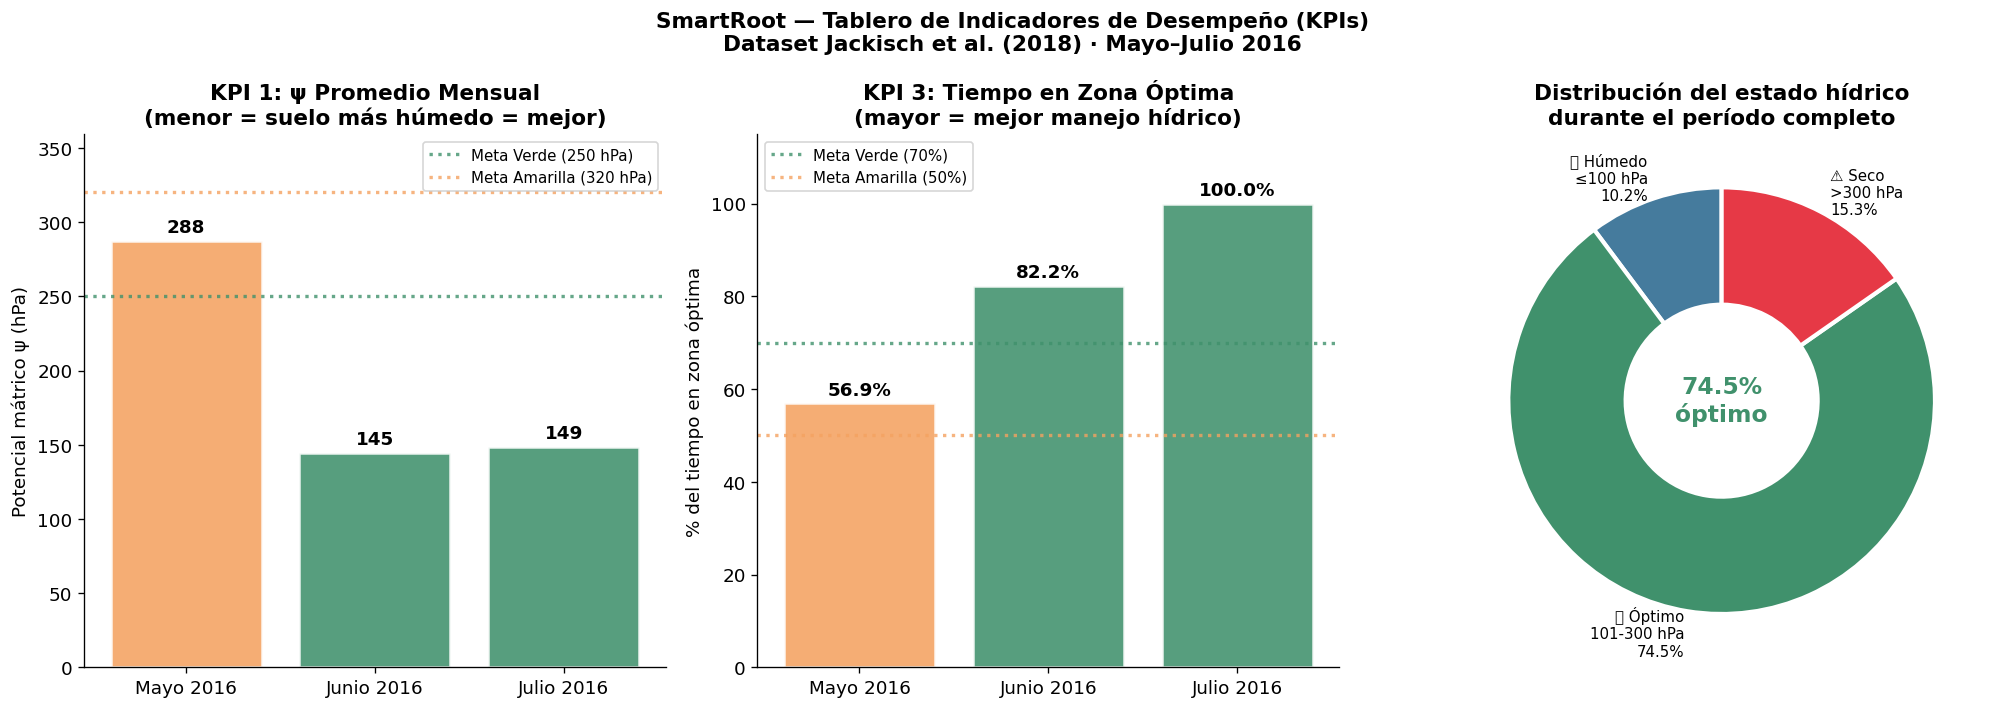

💾 Guardado: outputs/figuras/02_tablero_kpis.png


In [10]:
# ── Gráfico de barras: KPIs mensuales con colores de semáforo ─────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('SmartRoot — Tablero de Indicadores de Desempeño (KPIs)\n'
             'Dataset Jackisch et al. (2018) · Mayo–Julio 2016',
             fontsize=13, fontweight='bold')

# ── Gráfico 1: ψ promedio mensual ──
ax = axes[0]
colores_psi = [VERDE if v <= 250 else AMARILLO if v <= 320 else ROJO
               for v in df_mensual['psi_prom']]
barras = ax.bar(df_mensual['mes'], df_mensual['psi_prom'],
                color=colores_psi, alpha=0.88, edgecolor='white', linewidth=1.5)
ax.axhline(250, color=VERDE,    linestyle=':', lw=2, alpha=0.8, label='Meta Verde (250 hPa)')
ax.axhline(320, color=AMARILLO, linestyle=':', lw=2, alpha=0.8, label='Meta Amarilla (320 hPa)')
for b, v in zip(barras, df_mensual['psi_prom']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
            f'{v:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Potencial mátrico ψ (hPa)')
ax.set_title('KPI 1: ψ Promedio Mensual\n(menor = suelo más húmedo = mejor)')
ax.legend(fontsize=9)
ax.set_ylim(0, df_mensual['psi_prom'].max() * 1.25)

# ── Gráfico 2: % tiempo en zona óptima mensual ──
ax2 = axes[1]
colores_opt = [VERDE if v >= 70 else AMARILLO if v >= 50 else ROJO
               for v in df_mensual['pct_optimo']]
barras2 = ax2.bar(df_mensual['mes'], df_mensual['pct_optimo'],
                  color=colores_opt, alpha=0.88, edgecolor='white', linewidth=1.5)
ax2.axhline(70, color=VERDE,    linestyle=':', lw=2, alpha=0.8, label='Meta Verde (70%)')
ax2.axhline(50, color=AMARILLO, linestyle=':', lw=2, alpha=0.8, label='Meta Amarilla (50%)')
for b, v in zip(barras2, df_mensual['pct_optimo']):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('% del tiempo en zona óptima')
ax2.set_title('KPI 3: Tiempo en Zona Óptima\n(mayor = mejor manejo hídrico)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 115)

# ── Gráfico 3: Dona de distribución del estado hídrico global ──
ax3 = axes[2]
valores_dona   = [EDA_PCT_HUMEDO, EDA_PCT_OPTIMO, EDA_PCT_SECO]
labels_dona    = [
    f'💧 Húmedo\n≤100 hPa\n{EDA_PCT_HUMEDO}%',
    f'✅ Óptimo\n101-300 hPa\n{EDA_PCT_OPTIMO}%',
    f'⚠️ Seco\n>300 hPa\n{EDA_PCT_SECO}%',
]
colores_dona = [AZUL, VERDE, ROJO]
wedges, texts = ax3.pie(
    valores_dona, labels=labels_dona, colors=colores_dona,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)
)
for t in texts:
    t.set_fontsize(9)
ax3.text(0, 0, f'{EDA_PCT_OPTIMO}%\nóptimo',
         ha='center', va='center', fontsize=14,
         fontweight='bold', color=VERDE)
ax3.set_title('Distribución del estado hídrico\ndurante el período completo')

plt.tight_layout()
plt.savefig(f'{FIGS}/02_tablero_kpis.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Guardado: outputs/figuras/02_tablero_kpis.png')

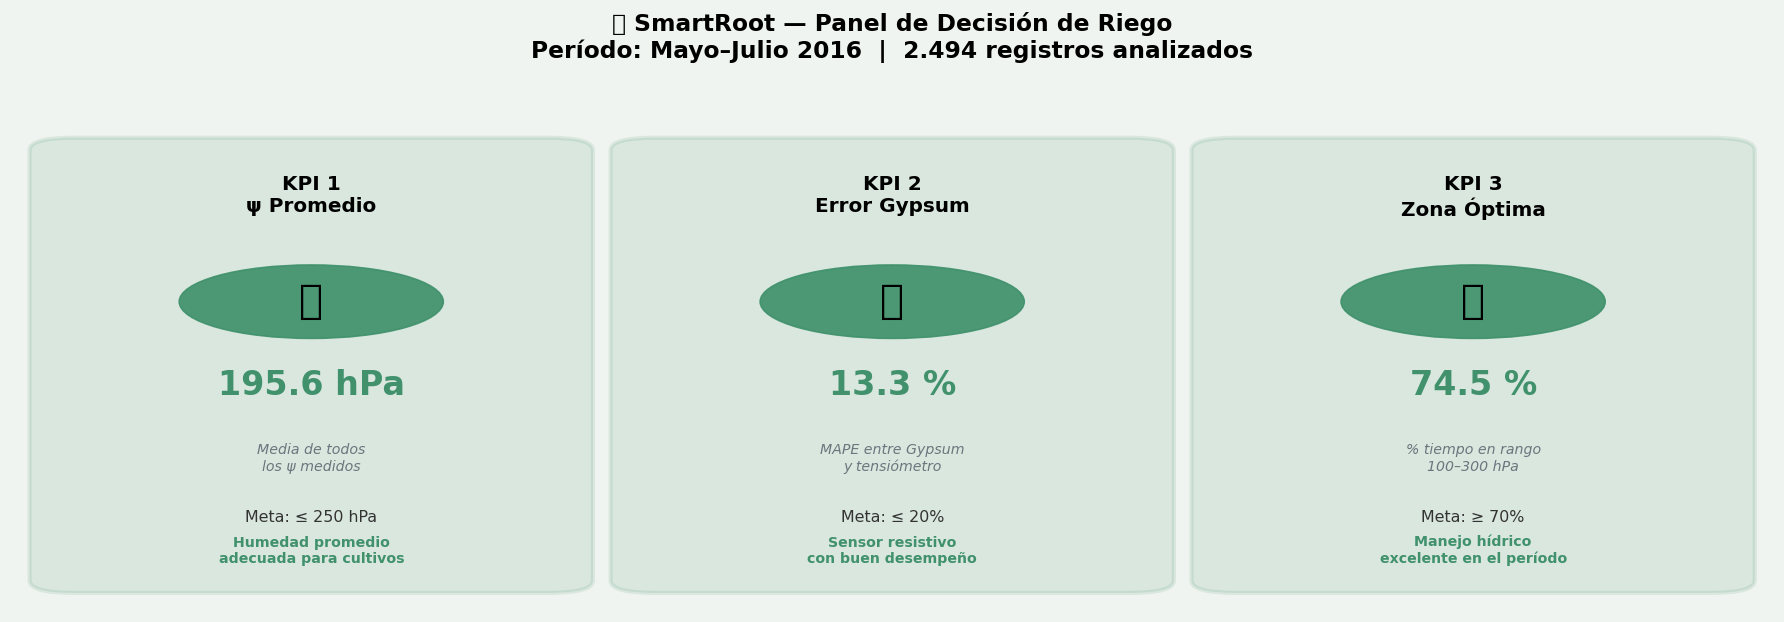

💾 Guardado: outputs/figuras/02_panel_semaforo.png

💡 Este panel es lo que el agricultor verá en su celular o tablet.
   Tres colores le dicen inmediatamente si debe o no regar hoy.


In [11]:
# ── Panel visual de semáforo para el agricultor ───────────────────────────
# Esta visualización es la interfaz del sistema SmartRoot para el usuario final.
# Tres tarjetas con colores claros permiten tomar la decisión de riego
# de un vistazo, sin necesidad de interpretar números.

fig, ax = plt.subplots(figsize=(15, 5))
ax.axis('off')
fig.patch.set_facecolor('#f0f4f0')

fig.suptitle('🌱 SmartRoot — Panel de Decisión de Riego\n'
             'Período: Mayo–Julio 2016  |  2.494 registros analizados',
             fontsize=14, fontweight='bold', y=1.03)

kpis_panel = [
    {'nombre': 'KPI 1\nψ Promedio',    'valor': f"{kpi1['valor']} hPa",
     'formula': 'Media de todos\nlos ψ medidos',
     'meta': 'Meta: ≤ 250 hPa',
     'interp': 'Humedad promedio\nadecuada para cultivos',
     'sem': semaforo_kpi1},
    {'nombre': 'KPI 2\nError Gypsum',  'valor': f"{kpi2['valor']} %",
     'formula': 'MAPE entre Gypsum\ny tensiómetro',
     'meta': 'Meta: ≤ 20%',
     'interp': 'Sensor resistivo\ncon buen desempeño',
     'sem': semaforo_kpi2},
    {'nombre': 'KPI 3\nZona Óptima',   'valor': f"{kpi3['valor']} %",
     'formula': '% tiempo en rango\n100–300 hPa',
     'meta': 'Meta: ≥ 70%',
     'interp': 'Manejo hídrico\nexcelente en el período',
     'sem': semaforo_kpi3},
]

for i, kp in enumerate(kpis_panel):
    xc    = 0.17 + i * 0.33
    color = kp['sem']['color']
    emoji = kp['sem']['emoji']

    # Tarjeta de fondo
    rect = mpatches.FancyBboxPatch(
        (xc - 0.135, 0.06), 0.27, 0.88,
        boxstyle='round,pad=0.025', facecolor=color,
        alpha=0.13, edgecolor=color, linewidth=2.5,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    ax.text(xc, 0.89, kp['nombre'], ha='center', va='top',
            fontsize=12, fontweight='bold', transform=ax.transAxes)

    circ = plt.Circle((xc, 0.63), 0.075, color=color, alpha=0.92,
                       transform=ax.transAxes)
    ax.add_patch(circ)
    ax.text(xc, 0.63, emoji, ha='center', va='center',
            fontsize=24, transform=ax.transAxes)

    ax.text(xc, 0.46, kp['valor'], ha='center', va='center',
            fontsize=20, fontweight='bold', color=color,
            transform=ax.transAxes)

    ax.text(xc, 0.31, kp['formula'], ha='center', va='center',
            fontsize=8.5, color=GRIS, style='italic',
            transform=ax.transAxes)

    ax.text(xc, 0.19, kp['meta'], ha='center', va='center',
            fontsize=9.5, color='#333', transform=ax.transAxes)

    ax.text(xc, 0.09, kp['interp'], ha='center', va='bottom',
            fontsize=8.5, color=color, fontweight='bold',
            transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f'{FIGS}/02_panel_semaforo.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Guardado: outputs/figuras/02_panel_semaforo.png')
print()
print('💡 Este panel es lo que el agricultor verá en su celular o tablet.')
print('   Tres colores le dicen inmediatamente si debe o no regar hoy.')

---
## Sección 7 — Resumen del notebook

In [12]:
print('=' * 72)
print('  RESUMEN — NOTEBOOK 02: PROGRAMACIÓN BÁSICA EN PYTHON')
print('  Proyecto SmartRoot')
print('=' * 72)

elementos = [
    ('Variables declaradas',  '18 variables de configuración (umbrales, parámetros, metadatos)'),
    ('Condicionales if/elif', 'Validación de rangos, clasificación calidad, semáforo'),
    ('Ciclo for',             f'Validación de {len(df):,} registros + análisis mensual (3 meses)'),
    ('Ciclo while',           f'Corrección iterativa de temperatura ({n_corregidos:,} registros)'),
    ('Validación de datos',   'Función validar_registro() con 8 variables y rangos físicos'),
    ('5 funciones propias',   'KPI1, KPI2, KPI3, semáforo, tabla de resultados'),
    ('KPI 1 — ψ promedio',    f"{kpi1['valor']} hPa → {semaforo_kpi1['emoji']} {semaforo_kpi1['clasificacion']}"),
    ('KPI 2 — MAPE Gypsum',   f"{kpi2['valor']} %  → {semaforo_kpi2['emoji']} {semaforo_kpi2['clasificacion']}"),
    ('KPI 3 — Zona óptima',   f"{kpi3['valor']} %  → {semaforo_kpi3['emoji']} {semaforo_kpi3['clasificacion']}"),
    ('Archivos generados',    'dataset_corregido.csv + tabla_indicadores_kpi.csv + 2 figuras'),
]
for elem, desc in elementos:
    print(f'  {elem:<28} : {desc}')

print()
print('─' * 72)
print('  COBERTURA DE REQUISITOS OBLIGATORIOS (Rúbrica del trabajo)')
print('─' * 72)
requisitos = [
    ('✅', 'Declaración y uso de variables',             'Sección 1 — 18 variables descriptivas'),
    ('✅', 'Carga y entrada de datos',                   'Sección 1 — dataset_limpio.csv'),
    ('✅', 'Condicionales if / elif / else',             'Secciones 2, 3, 4 y 5'),
    ('✅', 'Ciclo for',                                  'Sección 2 — validación; Sección 5 — mensual'),
    ('✅', 'Ciclo while',                                'Sección 2 — corrección de temperatura'),
    ('✅', 'Validación básica de datos',                 'Sección 2 — función validar_registro()'),
    ('✅', 'Comentarios explicativos',                   'Todo el notebook — docstrings + inline'),
    ('✅', 'Función para calcular indicador',            'calcular_kpi_potencial/variabilidad/tiempo_optimo()'),
    ('✅', 'Función para clasificar resultado',          'clasificar_semaforo()'),
    ('✅', 'Función para mostrar/consolidar resultados', 'mostrar_tabla_indicadores()'),
    ('✅', 'Mínimo 3 KPIs con fórmula/meta/semáforo',   'Sección 4 — KPI1, KPI2, KPI3 documentados'),
    ('✅', 'Gráfico de barras',                          'Sección 6 — KPIs mensuales con colores semáforo'),
    ('✅', 'Tabla de indicadores exportada',             'Sección 4 — tabla_indicadores_kpi.csv'),
]
for estado, req, donde in requisitos:
    print(f'  {estado} {req:<46} → {donde}')

print()
print('─' * 72)
print('  PRÓXIMO NOTEBOOK → 03_POO_indicadores.ipynb')
print('  Programación Orientada a Objetos: clases Sensor, SensorResistivo,')
print('  Parcela — con herencia, polimorfismo y atributos del problema real.')
print('─' * 72)

  RESUMEN — NOTEBOOK 02: PROGRAMACIÓN BÁSICA EN PYTHON
  Proyecto SmartRoot
  Variables declaradas         : 18 variables de configuración (umbrales, parámetros, metadatos)
  Condicionales if/elif        : Validación de rangos, clasificación calidad, semáforo
  Ciclo for                    : Validación de 2,494 registros + análisis mensual (3 meses)
  Ciclo while                  : Corrección iterativa de temperatura (619 registros)
  Validación de datos          : Función validar_registro() con 8 variables y rangos físicos
  5 funciones propias          : KPI1, KPI2, KPI3, semáforo, tabla de resultados
  KPI 1 — ψ promedio           : 195.6 hPa → 🟢 VERDE
  KPI 2 — MAPE Gypsum          : 13.3 %  → 🟢 VERDE
  KPI 3 — Zona óptima          : 74.5 %  → 🟢 VERDE
  Archivos generados           : dataset_corregido.csv + tabla_indicadores_kpi.csv + 2 figuras

────────────────────────────────────────────────────────────────────────
  COBERTURA DE REQUISITOS OBLIGATORIOS (Rúbrica del trabajo)
────

---
## Referencias

**Dataset:**
> Jackisch, C. et al. (2018). *Soil moisture and matric potential – An open field comparison of sensor systems* [Dataset]. PANGAEA. https://doi.org/10.1594/PANGAEA.892319

**Umbrales agronómicos:**
> Rawls, W. J., Brakensiek, D. L., & Saxtonn, K. E. (1982). Estimation of soil water properties. *Transactions of the ASAE*, 25(5), 1316–1320.
> FAO (2002). *Deficit irrigation practices*. FAO Water Reports 22.

**Indicadores de error:**
> Chai, T., & Draxler, R. R. (2014). Root mean square error (RMSE) or mean absolute error (MAE)? *Geoscientific Model Development*, 7(3), 1247–1250.

---
*Notebook 02/05 — Proyecto SmartRoot · Fundamentos de Programación Científica · 2026-1*